Your exons: n=366, range 3-3807 bp
GTF: gencode.v46.annotation.gtf.gz (51.0 MB)
Parsing GTF (extracting exon features)...
  Total exon feature rows: 1,668,627
  Unique exon intervals: 670,419
  Length range: 1-347300 bp, median 159 bp
Microexon (<= 51 bp): neuronal-specific 57.1%, all human 7.22%


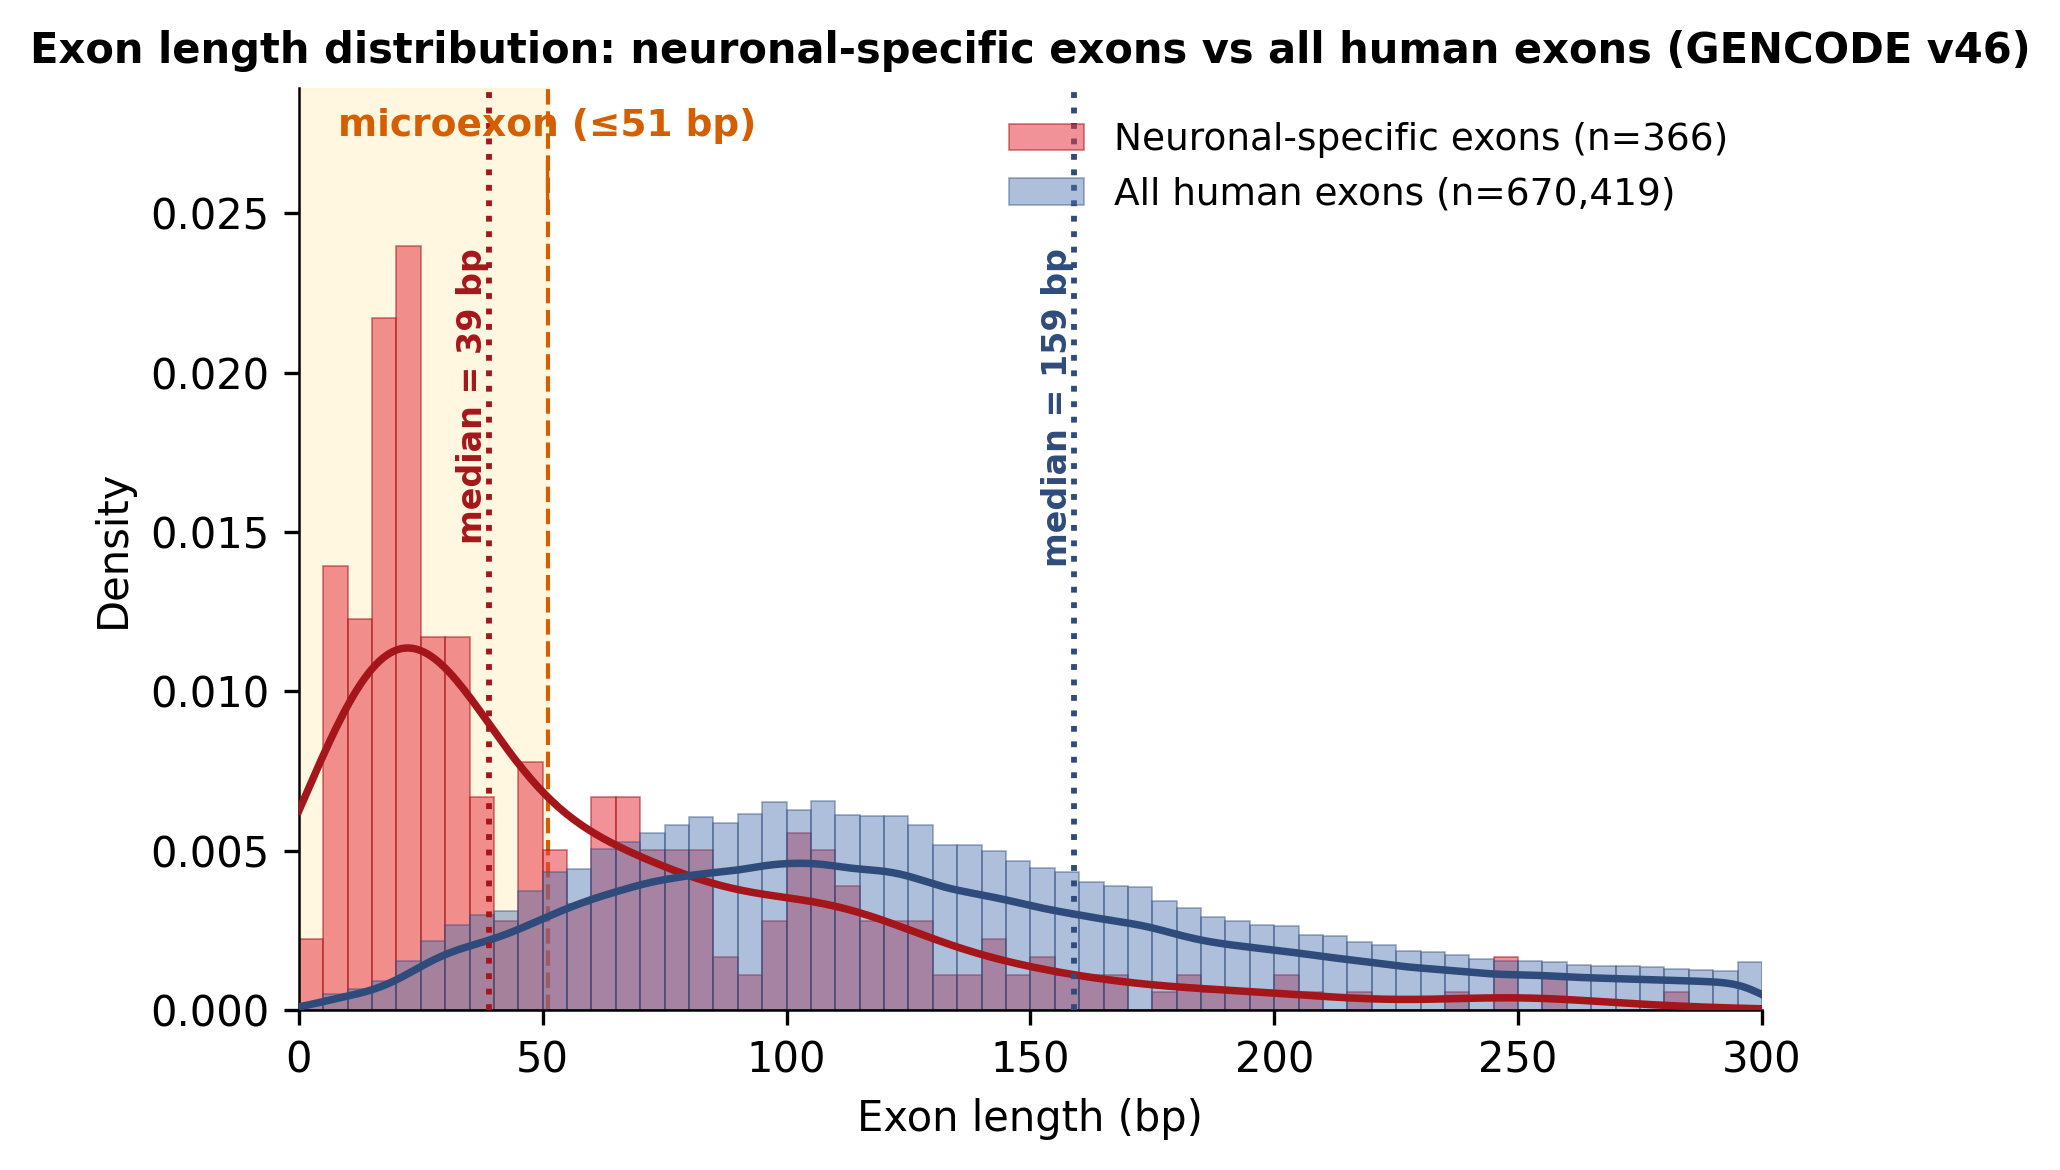

Saved: ../exon_length_distribution.png / ../exon_length_distribution.svg


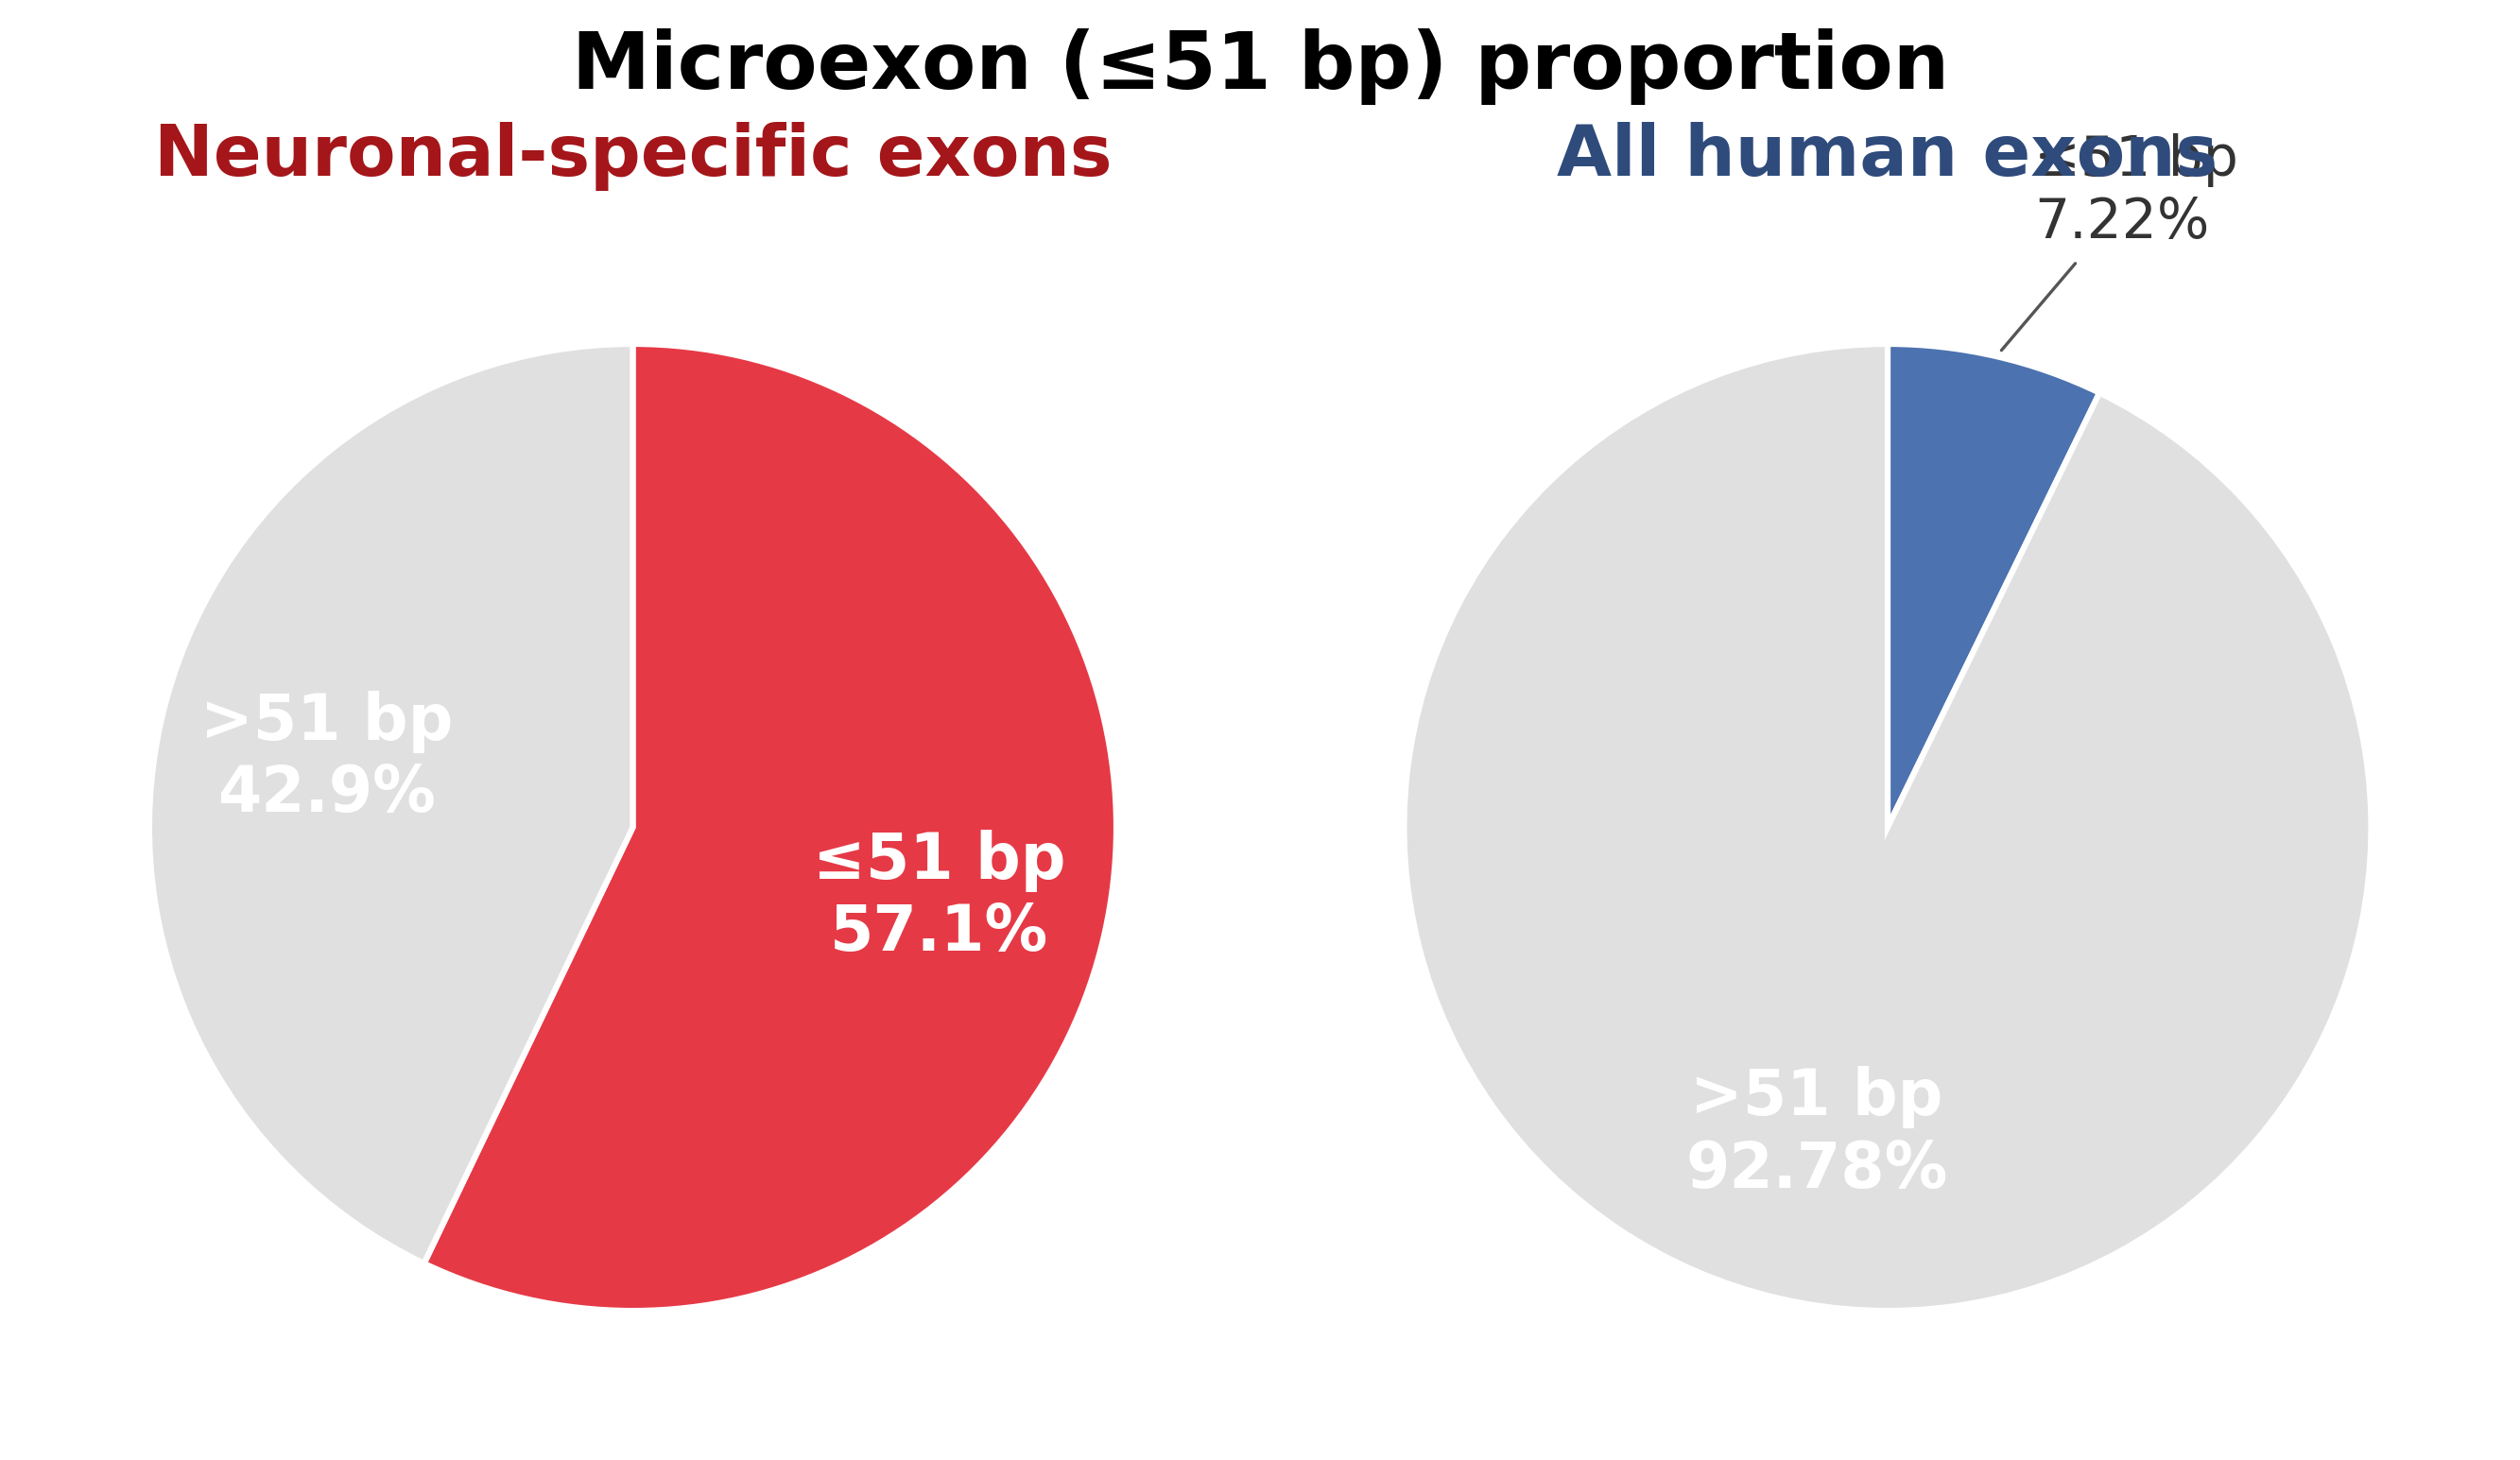

Saved: ../exon_microexon_pie.png / ../exon_microexon_pie.svg


In [1]:
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde

# ---- Config ----
CSV_PATH   = "../outputs/neuron_up_exon_conserved.csv"                                  # <-- change to your path
GTF_URL    = "https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_46/gencode.v46.annotation.gtf.gz"
GTF_LOCAL  = "gencode.v46.annotation.gtf.gz"                   # cached locally
OUT_PNG    = "../outputs/exon_length_distribution.png"
OUT_SVG    = "../outputs/exon_length_distribution.svg"
PIE_PNG    = "../outputs/exon_microexon_pie.png"
PIE_SVG    = "../outputs/exon_microexon_pie.svg"
MICROEXON_CUTOFF = 51
X_MAX      = 300
BIN_WIDTH  = 5
FONT_SIZE  = 10
PIE_FONT   = 16

# ---- Fonts: Arial, single size ----
matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE, "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE, "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
    "figure.dpi": 300, "savefig.dpi": 300,
    "pdf.fonttype": 42, "ps.fonttype": 42, "axes.linewidth": 0.6,
    "svg.fonttype": "none",
})

# ---- 1. Load your exons ----
df = pd.read_csv(CSV_PATH)
your_exons = df["LENGTH"].astype(float).values
print(f"Your exons: n={len(your_exons)}, range {your_exons.min():.0f}-{your_exons.max():.0f} bp")

# ---- 2. Download GENCODE v46 GTF (cached) ----
if not (os.path.exists(GTF_LOCAL) and os.path.getsize(GTF_LOCAL) > 1e6):
    print(f"Downloading GENCODE v46 GTF (~50 MB)...")
    urllib.request.urlretrieve(GTF_URL, GTF_LOCAL)
print(f"GTF: {GTF_LOCAL} ({os.path.getsize(GTF_LOCAL)/1e6:.1f} MB)")

# ---- 3. Parse GTF -> unique exon intervals -> lengths ----
import gzip
print("Parsing GTF (extracting exon features)...")
rows = []
with gzip.open(GTF_LOCAL, "rt") as f:
    for line in f:
        if line.startswith("#"):
            continue
        fields = line.rstrip("\n").split("\t")
        if len(fields) < 9 or fields[2] != "exon":
            continue
        rows.append((fields[0], int(fields[3]), int(fields[4]), fields[6]))
print(f"  Total exon feature rows: {len(rows):,}")
unique = set(rows)
print(f"  Unique exon intervals: {len(unique):,}")
all_exons = np.array([e - s + 1 for (_, s, e, _) in unique], dtype=float)
print(f"  Length range: {all_exons.min():.0f}-{all_exons.max():.0f} bp, median {np.median(all_exons):.0f} bp")

# ---- 4. Microexon percentages ----
pct_yours = (your_exons <= MICROEXON_CUTOFF).mean() * 100
pct_all   = (all_exons  <= MICROEXON_CUTOFF).mean() * 100
print(f"Microexon (<= {MICROEXON_CUTOFF} bp): neuronal-specific {pct_yours:.1f}%, all human {pct_all:.2f}%")

# ---- 5. Distribution plot (histograms + KDE + median lines) ----
fig, ax = plt.subplots(figsize=(6, 4), facecolor="white")

bins = np.arange(0, X_MAX + BIN_WIDTH, BIN_WIDTH)

# Shade microexon region
ax.axvspan(0, MICROEXON_CUTOFF, color="#FFF2CC", alpha=0.6, zorder=0)
ax.axvline(MICROEXON_CUTOFF, color="#D55E00", linestyle="--", linewidth=1.0, zorder=1)

# Overlaid density histograms (zoom to 0-X_MAX; tail exons clipped out of view)
ax.hist(your_exons, bins=bins, density=True, alpha=0.55,
        color="#E63946", edgecolor="#A4161A", linewidth=0.4,
        label=f"Neuronal-specific exons (n={len(your_exons)})", zorder=2)
ax.hist(all_exons, bins=bins, density=True, alpha=0.45,
        color="#4C72B0", edgecolor="#2F4B7C", linewidth=0.4,
        label=f"All human exons (n={len(all_exons):,})", zorder=2)

# KDE curves (gaussian_kde on zoomed subset, rescaled by fraction in window)
x_grid  = np.linspace(0, X_MAX, 400)
ye_zoom = your_exons[your_exons <= X_MAX]
ae_zoom = all_exons[all_exons  <= X_MAX]
kde_y   = gaussian_kde(ye_zoom)
kde_a   = gaussian_kde(ae_zoom)
frac_y  = len(ye_zoom) / len(your_exons)
frac_a  = len(ae_zoom) / len(all_exons)
ax.plot(x_grid, kde_y(x_grid) * frac_y, color="#A4161A", linewidth=1.8, zorder=3)
ax.plot(x_grid, kde_a(x_grid) * frac_a, color="#2F4B7C", linewidth=1.8, zorder=3)

# Median length lines for both distributions
med_yours = float(np.median(your_exons))
med_all   = float(np.median(all_exons))
y_top_pre = ax.get_ylim()[1]
ax.axvline(med_yours, color="#A4161A", linestyle=":", linewidth=1.4, zorder=3)
ax.axvline(med_all,   color="#2F4B7C", linestyle=":", linewidth=1.4, zorder=3)
ax.text(med_yours, y_top_pre * 0.95, f"median = {med_yours:.0f} bp",
        rotation=90, va="top", ha="right", fontsize=FONT_SIZE - 2,
        color="#A4161A", fontweight="bold")
ax.text(med_all, y_top_pre * 0.95, f"median = {med_all:.0f} bp",
        rotation=90, va="top", ha="right", fontsize=FONT_SIZE - 2,
        color="#2F4B7C", fontweight="bold")

ax.set_xlim(0, X_MAX)
ax.set_xlabel("Exon length (bp)")
ax.set_ylabel("Density")
ax.set_title("Exon length distribution: neuronal-specific exons vs all human exons (GENCODE v46)",
             fontweight="bold", fontsize=FONT_SIZE)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Microexon label — placed ABOVE the plot area (not overlapping bars)
y_top = ax.get_ylim()[1]
ax.annotate("microexon (≤51 bp)",
            xy=(MICROEXON_CUTOFF, y_top), xytext=(MICROEXON_CUTOFF, y_top * 1.08),
            ha="center", va="bottom",
            fontsize=FONT_SIZE - 1, color="#D55E00", fontweight="bold",
            arrowprops=dict(arrowstyle="-", color="#D55E00", linewidth=0.8))
ax.set_ylim(0, y_top * 1.15)

ax.legend(loc="upper right", frameon=False, fontsize=FONT_SIZE - 1)

fig.tight_layout()
fig.savefig(OUT_PNG, bbox_inches="tight", facecolor="white")
fig.savefig(OUT_SVG, bbox_inches="tight", facecolor="white")
plt.show()   # display inline in the notebook
print(f"Saved: {OUT_PNG} / {OUT_SVG}")

# ---- 6. Separate pie-chart figure (labels inside wedges) ----
fig2, axes = plt.subplots(1, 2, figsize=(9, 5), facecolor="white")

def _draw_pie(ax, sizes, colors, title, title_color, labels):
    """Draw pie with labels inside wedges; tiny wedges use a leader line."""
    wedges, _ = ax.pie(
        sizes, colors=colors, startangle=90, counterclock=False,
        wedgeprops=dict(edgecolor="white", linewidth=1.5),
    )
    ax.set_title(title, fontsize=PIE_FONT + 2, color=title_color,
                 fontweight="bold", pad=12)
    for w, lab in zip(wedges, labels):
        ang = (w.theta2 + w.theta1) / 2.0
        x = np.cos(np.deg2rad(ang)) * 0.65
        y = np.sin(np.deg2rad(ang)) * 0.65
        frac = (w.theta2 - w.theta1) / 360.0
        if frac >= 0.12:
            # large enough -> label inside the wedge
            ax.text(x, y, lab, ha="center", va="center",
                    fontsize=PIE_FONT, fontweight="bold",
                    color="k" if frac > 0.4 else "#333333")
        else:
            # tiny wedge -> leader line + outside label
            x_out = np.cos(np.deg2rad(ang)) * 1.35
            y_out = np.sin(np.deg2rad(ang)) * 1.35
            ax.annotate(lab, xy=(np.cos(np.deg2rad(ang)) * 1.0,
                                 np.sin(np.deg2rad(ang)) * 1.0),
                        xytext=(x_out, y_out),
                        ha="center" if -0.3 < x_out < 0.3 else ("left" if x_out > 0 else "right"),
                        va="center", fontsize=PIE_FONT - 2,
                        color="#333333",
                        arrowprops=dict(arrowstyle="-", color="#555555", linewidth=0.8))

# Pie 1: neuronal-specific exons (63.4% / 36.6% — both wedges large)
_draw_pie(axes[0], [pct_yours, 100 - pct_yours],
          ["#E63946", "#E0E0E0"],
          "Neuronal-specific exons", "#A4161A",
          [f"≤51 bp\n{pct_yours:.1f}%", f">51 bp\n{100 - pct_yours:.1f}%"])

# Pie 2: all human exons (7.22% / 92.78% — small wedge needs leader line)
_draw_pie(axes[1], [pct_all, 100 - pct_all],
          ["#4C72B0", "#E0E0E0"],
          "All human exons", "#2F4B7C",
          [f"≤51 bp\n{pct_all:.2f}%", f">51 bp\n{100 - pct_all:.2f}%"])

fig2.suptitle("Microexon (≤51 bp) proportion", fontweight="bold",
              fontsize=PIE_FONT + 4, y=1.02)
fig2.tight_layout()
fig2.savefig(PIE_PNG, bbox_inches="tight", facecolor="white")
fig2.savefig(PIE_SVG, bbox_inches="tight", facecolor="white")
plt.show()   # display inline in the notebook
print(f"Saved: {PIE_PNG} / {PIE_SVG}")